# ESA Biomass Level 1B COG georeferencing

The Level 1B 

In [1]:
import os
from urllib.parse import urlsplit

import matplotlib.pyplot as plt
import numpy as np
import obstore as obs
import requests
import rasterio
import xarray as xr
from netCDF4 import Dataset
from obstore.store import HTTPStore
from pystac_client import Client
from rasterio.crs import CRS
from rasterio.enums import Resampling
from rasterio.plot import show
from rasterio.transform import GCPTransformer, array_bounds, from_origin, from_bounds
from rasterio.warp import calculate_default_transform, reproject, transform, transform_bounds
from rasterio.windows import Window
from shapely.geometry import box
from scipy.ndimage import map_coordinates
from xml.etree import ElementTree


STAC_API_URL = "https://catalog.maap.eo.esa.int/catalogue"
TOKEN_URL = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
POLARIZATIONS = ("HH", "HV", "VH", "VV")

BBOX = (108.06,61.89,108.16,61.92)  # AOI covering a nice river bend
CRS = CRS.from_string("EPSG:32649")  # approriate UTM zone
TARGET_RESOLUTION = 25

In [2]:
raw_bbox = transform_bounds("EPSG:4326", CRS, *BBOX)

grid_xmin = np.floor(raw_bbox[0] / TARGET_RESOLUTION) * TARGET_RESOLUTION
grid_ymin = np.floor(raw_bbox[1] / TARGET_RESOLUTION) * TARGET_RESOLUTION
grid_xmax = np.ceil(raw_bbox[2] / TARGET_RESOLUTION) * TARGET_RESOLUTION
grid_ymax = np.ceil(raw_bbox[3] / TARGET_RESOLUTION) * TARGET_RESOLUTION

TARGET_BBOX = (grid_xmin, grid_ymin, grid_xmax, grid_ymax)

TARGET_WIDTH = int((grid_xmax - grid_xmin) / TARGET_RESOLUTION)
TARGET_HEIGHT = int((grid_ymax - grid_ymin) / TARGET_RESOLUTION)

TARGET_TRANSFORM = from_bounds(*TARGET_BBOX, TARGET_WIDTH, TARGET_HEIGHT)
TARGET_SHAPE = (TARGET_HEIGHT, TARGET_WIDTH)

print(TARGET_HEIGHT, TARGET_WIDTH)
print(TARGET_TRANSFORM)

144 217
| 25.00, 0.00, 345475.00|
| 0.00,-25.00, 6868775.00|
| 0.00, 0.00, 1.00|


In [3]:
client = Client.open(STAC_API_URL)

search = client.search(
    collections="BiomassLevel1b",
    intersects=box(*BBOX),
    datetime="2026-06-01T00:00:00Z/2026-06-12T00:00:00Z",
    sortby="datetime",
    max_items=6,
)

items = search.item_collection()
print(f"found {len(items)} items")
for item in items:
    print(item.id)

found 3 items
BIO_S2_DGM__1S_20260601T121355_20260601T121415_T_G01_M03_C07_T008_F100_02_DSD6MY
BIO_S3_DGM__1S_20260606T211626_20260606T211646_T_G01_M03_C01_T043_F056_02_DSMSWR
BIO_S3_DGM__1S_20260609T211628_20260609T211648_T_G01_M03_C02_T043_F056_02_DSSCXA


In [4]:
client_secret = os.getenv("ESA_MAAP_CLIENT_SECRET")
offline_token = os.getenv("ESA_OFFLINE_TOKEN")

def request_access_token(client_secret: str, offline_token: str) -> str:
    """Exchange supplied MAAP credentials for an access token."""

    if not client_secret or not offline_token:
        raise ValueError("Missing MAAP credentials")
        
    response = requests.post(
        TOKEN_URL,
        data={
            "client_id": "offline-token",
            "client_secret": client_secret,
            "grant_type": "refresh_token",
            "refresh_token": offline_token,
            "scope": "offline_access openid",
        },
        timeout=60,
    )
    response.raise_for_status()
    token = response.json().get("access_token")
    
    if not token:
        raise RuntimeError("Failed to retrieve an access token from the IAM response")
    
    return token

token = request_access_token(client_secret, offline_token)

In [43]:
with rasterio.Env(GDAL_HTTP_HEADERS=f"Authorization: Bearer {token}"):
    with rasterio.open(items[0].assets["enclosure_tiff"].href) as src:
        reprojected = np.full(
            (len(items), src.count, TARGET_HEIGHT, TARGET_WIDTH),
            np.nan,
            dtype=src.meta["dtype"],
        )

    for i, item in enumerate(items):
        with rasterio.open(item.assets["enclosure_tiff"].href) as src:
            gcps, gcp_crs = src.gcps
                                
            reproject(
                source=rasterio.band(src, src.indexes),
                destination=reprojected[i],
                gcps=gcps,
                src_crs=gcp_crs,
                dst_transform=TARGET_TRANSFORM,
                dst_crs=CRS,
                resampling=Resampling.nearest,
                dst_nodata=np.nan,
            )

In [44]:
x = TARGET_TRANSFORM.c + TARGET_TRANSFORM.a * (np.arange(TARGET_WIDTH) + 0.5)
y = TARGET_TRANSFORM.f + TARGET_TRANSFORM.e * (np.arange(TARGET_HEIGHT) + 0.5)

gcp_da = xr.DataArray(
    reprojected,
    dims=("id", "polarization", "y", "x"),
    coords={
        "id": [item.id for item in items],
        "polarization": list(POLARIZATIONS),
        "x": x,
        "y": y,
    },
    attrs={"crs": CRS, "transform": tuple(TARGET_TRANSFORM)},
)
gcp_da

<xarray.DataArray (id: 3, polarization: 4, y: 144, x: 217)> Size: 1MB
array([[[[0.5639333 , 0.80540895, 0.92140895, ..., 0.80951613,
          1.0223662 , 1.0223662 ],
         [0.57900894, 0.750609  , 0.51440895, ..., 0.82751614,
          0.7001662 , 0.7139662 ],
         [0.49772182, 0.46620896, 0.35900897, ..., 1.0537663 ,
          0.88196623, 0.7797662 ],
         ...,
         [0.22935534, 0.19989721, 0.16669722, ..., 0.42479962,
          0.28759962, 0.35039866],
         [0.15469722, 0.17289722, 0.17469722, ..., 0.45439962,
          0.42759866, 0.57519865],
         [0.18129721, 0.14289722, 0.19449721, ..., 0.6237996 ,
          0.50199866, 0.44839865]],

        [[0.21324724, 0.17684141, 0.2066414 , ..., 0.26979604,
          0.4361771 , 0.4361771 ],
         [0.16824141, 0.18004142, 0.22244142, ..., 0.23199603,
          0.34357712, 0.3635771 ],
         [0.20353967, 0.14924142, 0.1996414 , ..., 0.3129771 ,
          0.22437711, 0.2635771 ],
...
          0.09188145, 0.11988145],
         [0.09707982, 0.08967982, 0.07627982, ..., 0.13973533,
          0.13488145, 0.12688145],
         [0.06967982, 0.07867982, 0.07647982, ..., 0.14713532,
          0.14713532, 0.14708145]],

        [[0.2701869 , 0.2243869 , 0.2475869 , ..., 0.574813  ,
          0.660413  , 0.6047118 ],
         [0.37138692, 0.4457869 , 0.3355869 , ..., 0.602813  ,
          0.517813  , 0.47611177],
         [0.4745869 , 0.6311869 , 0.4513869 , ..., 0.46921304,
          0.48581302, 0.43301302],
         ...,
         [0.11639768, 0.11061105, 0.10901105, ..., 0.48653516,
          0.5468614 , 0.5698614 ],
         [0.15421104, 0.13861105, 0.14361106, ..., 0.56813514,
          0.50786144, 0.39866143],
         [0.14461105, 0.14401105, 0.14641105, ..., 0.49433517,
          0.49433517, 0.31626144]]]],
      shape=(3, 4, 144, 217), dtype=float32)
Coordinates:
  * id            (id) <U80 960B 'BIO_S2_DGM__1S_20260601T121355_20260601T121...
  * polarization  (polarization) <U2 32B 'HH' 'HV' 'VH' 'VV'
  * y             (y) float64 1kB 6.869e+06 6.869e+06 ... 6.865e+06 6.865e+06
  * x             (x) float64 2kB 3.455e+05 3.455e+05 ... 3.509e+05 3.509e+05
Attributes:
    crs:        EPSG:32649
    transform:  (np.float64(25.0), np.float64(0.0), np.float64(345475.0), np....

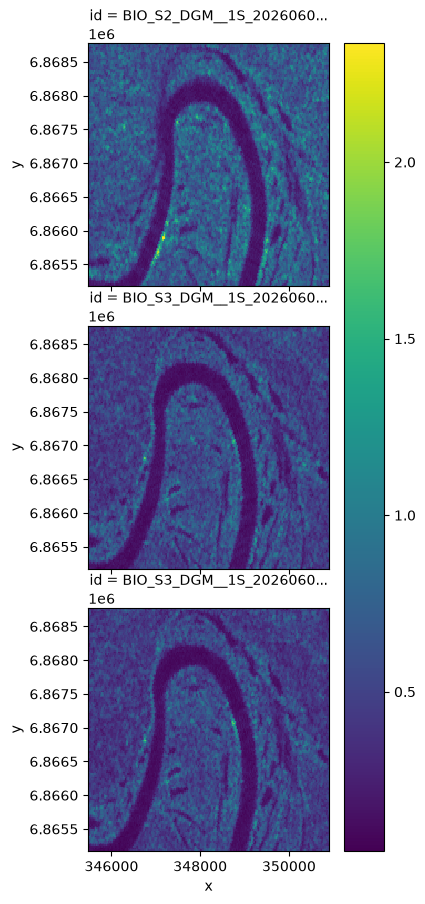

In [45]:
gcp_da.isel(polarization=0).plot.imshow(row="id")

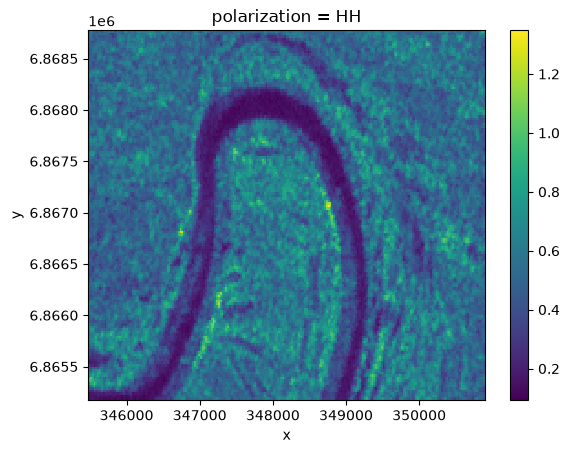

In [46]:
gcp_da.isel(polarization=0).mean(dim="id").plot.imshow()

In [47]:
with rasterio.Env(AWS_NO_SIGN_REQUEST=True):
    with rasterio.open(
        "https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/49/V/CJ/2026/6/S2C_T49VCJ_20260611T041739_L2A/TCI.tif"
    ) as src:
        s2 = np.full(
            (src.count, TARGET_HEIGHT, TARGET_WIDTH),
            src.nodata,
            dtype=src.meta["dtype"],
        )
            
        reproject(
            source=rasterio.band(src, src.indexes),
            destination=s2,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=TARGET_TRANSFORM,
            dst_crs=CRS,
            resampling=Resampling.nearest,
        )

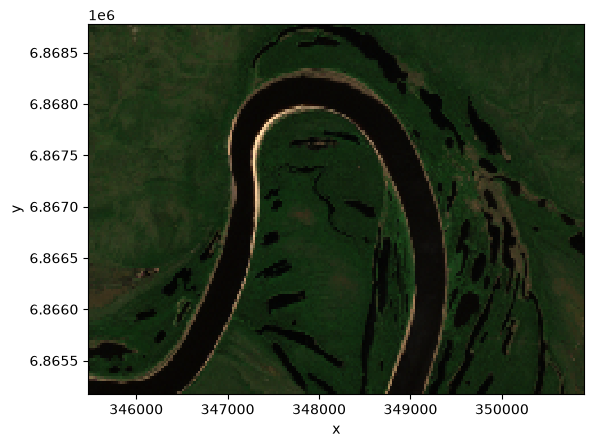

In [48]:
s2_da = xr.DataArray(
    s2,
    dims=("band", "y", "x"),
    coords={
        "band": ["red", "green", "blue"],
        "x": x,
        "y": y,
    },
    attrs={"crs": CRS, "transform": tuple(TARGET_TRANSFORM)},
)
s2_da.plot.imshow()

In [49]:
def water_mask(da: xr.DataArray) -> xr.DataArray:
    water = (
        (da.sel(polarization=["HH", "VV"]) < 0.30).all("polarization")
        & (da.sel(polarization=["HV", "VH"]) < 0.18).all("polarization")
    )
    
    return xr.where(water, 0, 1).astype("uint8")

gcp_water_mask = water_mask(gcp_da)

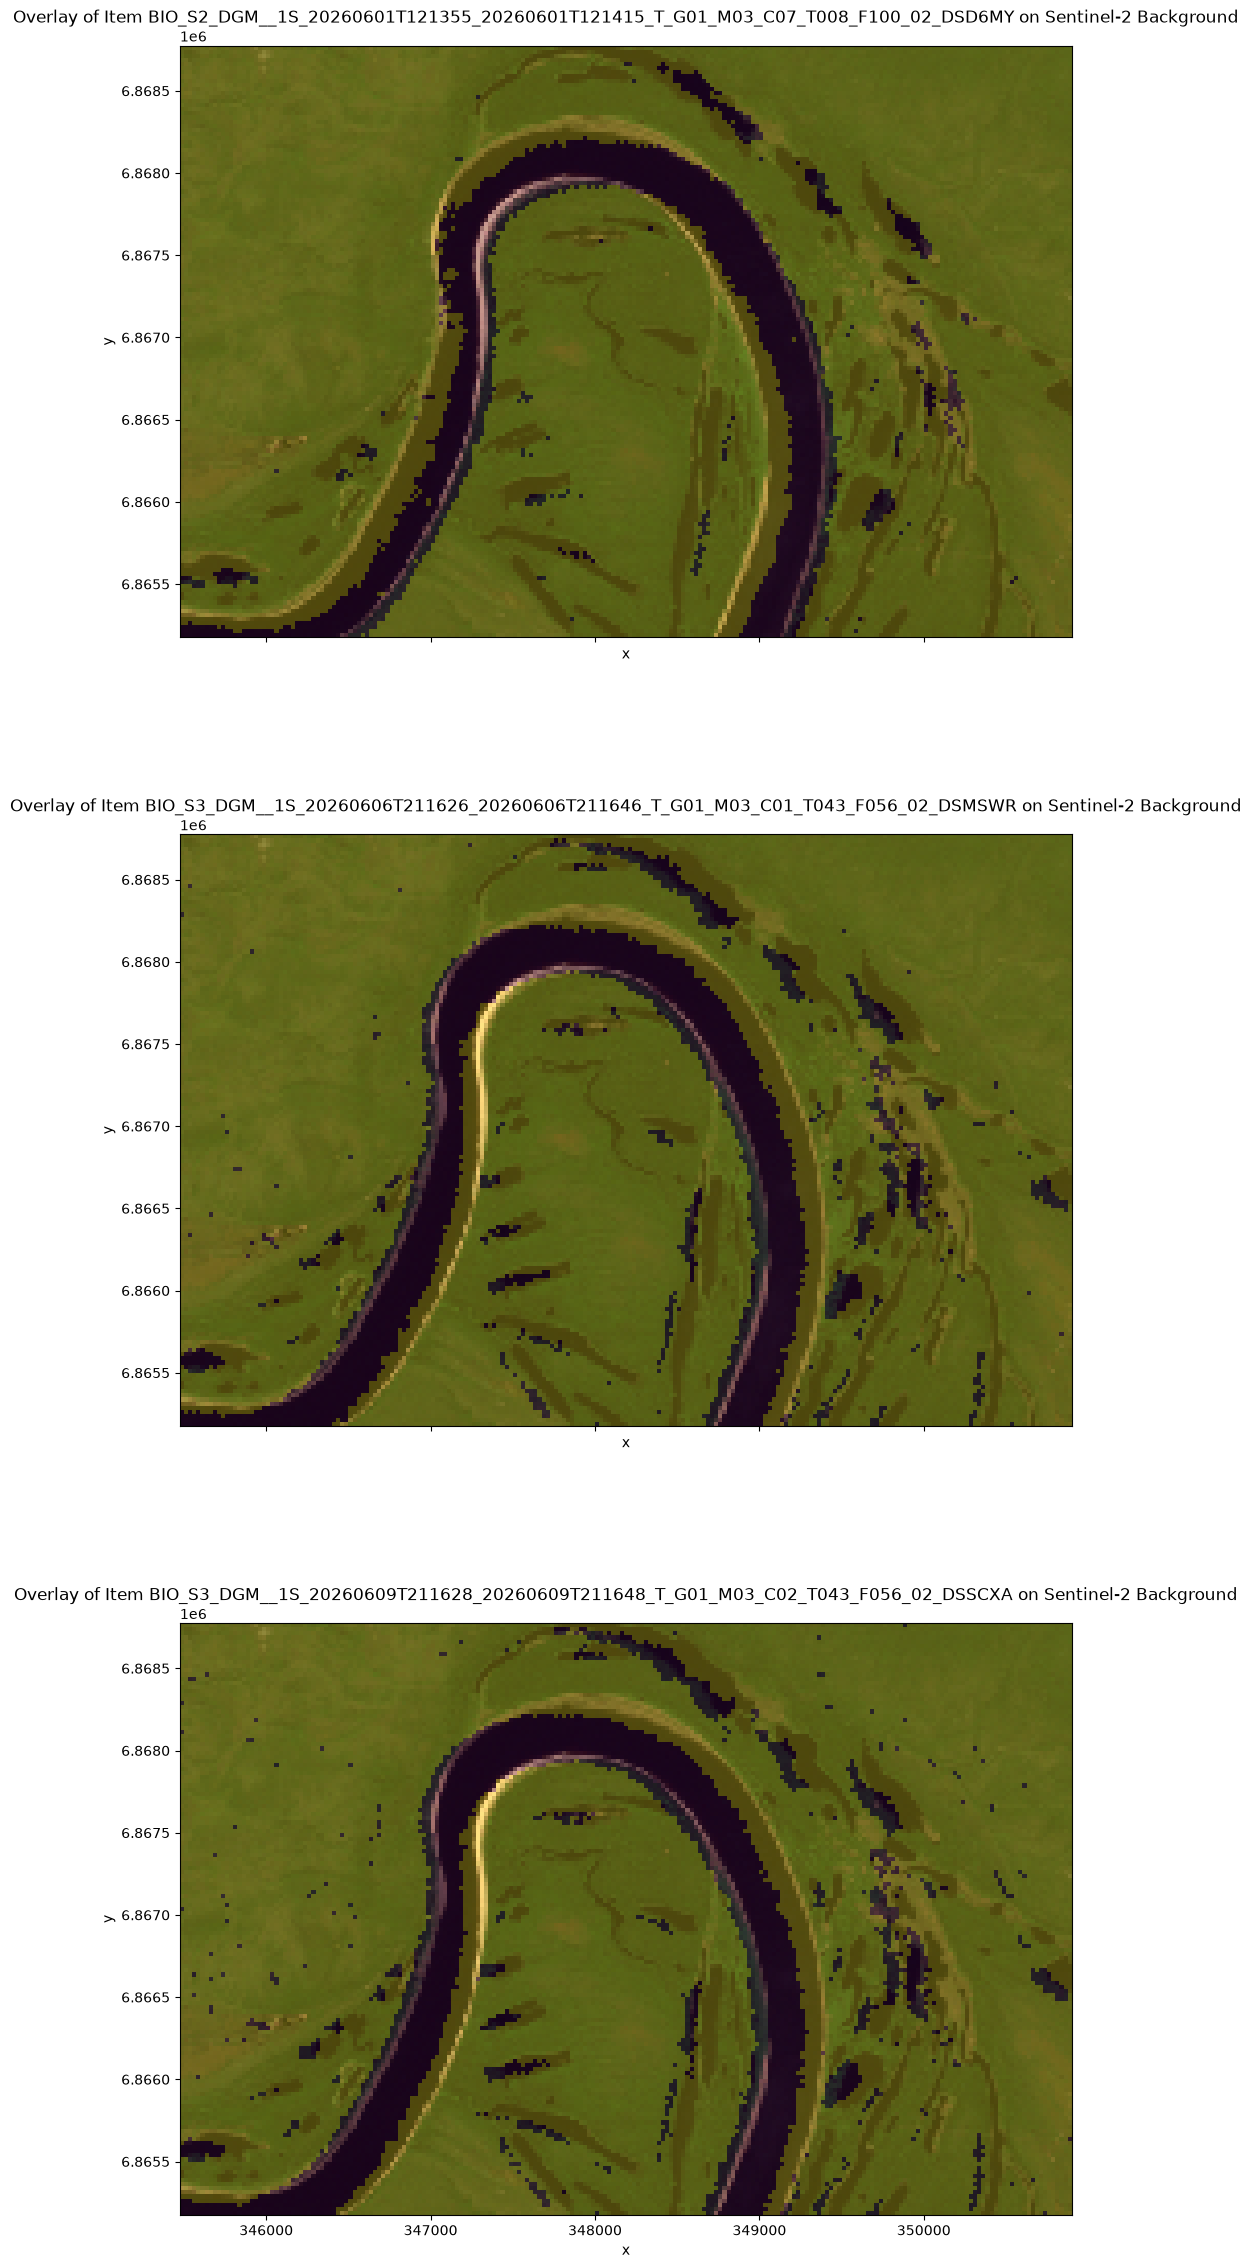

In [50]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 24), sharex=True, sharey=True)

for i, (item_id, ax) in enumerate(zip(gcp_da.id.values, axes)):
    
    s2_da.plot.imshow(rgb="band", ax=ax)
    
    gcp_water_mask.sel(id=item_id).plot.imshow(
        ax=ax, 
        alpha=0.3, 
        cmap="viridis",
        vmin=0,
        vmax=1,
        add_colorbar=False,
    )
    
    ax.set_title(f"Overlay of Item {item_id} on Sentinel-2 Background")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()


In [51]:
with rasterio.Env(GDAL_HTTP_HEADERS=f"Authorization: Bearer {token}"):
    with rasterio.open(items[0].assets["enclosure_tiff"].href) as src:
        reprojected = np.full(
            (len(items), src.count, TARGET_HEIGHT, TARGET_WIDTH),
            np.nan,
            dtype=src.meta["dtype"],
        )

    for i, item in enumerate(items):
        # Fetch the LUT and annotation directly into memory.
        asset_bytes = {}
        for key in ("enclosure_nc", "enclosure_annot_xml"):
            parsed_url = urlsplit(item.assets[key].href)
            store = HTTPStore(
                f"{parsed_url.scheme}://{parsed_url.netloc}",
                client_options={
                    "default_headers": {"Authorization": f"Bearer {token}"},
                    "timeout": "3m",
                },
            )
            response = await obs.get_async(store, parsed_url.path.lstrip("/"))
            asset_bytes[key] = bytes(await response.bytes_async())

        with Dataset(
            "geometry.nc", mode="r", memory=asset_bytes["enclosure_nc"]
        ) as lut:
            longitude_lut = np.asarray(lut["geometry/longitude"][:], dtype="float64")
            latitude_lut = np.asarray(lut["geometry/latitude"][:], dtype="float64")
            lut_azimuth = np.asarray(lut["relativeAzimuthTimeRGC"][:], dtype="float64")
            lut_slant_range = np.asarray(lut["slantRangeTimeRGC"][:], dtype="float64")

        sar_image = ElementTree.fromstring(asset_bytes["enclosure_annot_xml"]).find(
            "sarImage"
        )
        if sar_image is None:
            raise ValueError(f"{item.id}: annotation has no sarImage element")

        azimuth_interval = float(sar_image.findtext("azimuthTimeInterval"))
        range_pixel_spacing = float(sar_image.findtext("rangePixelSpacing"))
        ground_to_slant_coefficients = np.fromstring(
            sar_image.findtext(
                "rangeCoordinateConversion/coordinateConversion/"
                "groundToSlantCoefficients"
            ),
            sep=" ",
        )

        with rasterio.open(item.assets["enclosure_tiff"].href) as src:
            azimuth = np.arange(src.height, dtype="float64") * azimuth_interval
            slant_range = np.polynomial.polynomial.polyval(
                np.arange(src.width, dtype="float64") * range_pixel_spacing,
                ground_to_slant_coefficients,
            )
            if (
                azimuth[0] < lut_azimuth[0]
                or azimuth[-1] > lut_azimuth[-1]
                or slant_range[0] < lut_slant_range[0]
                or slant_range[-1] > lut_slant_range[-1]
            ):
                raise ValueError(f"{item.id}: Beta0 extent exceeds geometry LUT")

            lut_rows = np.interp(azimuth, lut_azimuth, np.arange(lut_azimuth.size))
            lut_columns = np.interp(
                slant_range, lut_slant_range, np.arange(lut_slant_range.size)
            )
            lut_row_grid, lut_column_grid = np.broadcast_arrays(
                lut_rows[:, np.newaxis],
                lut_columns[np.newaxis, :],
            )
            geolocation = tuple(
                map_coordinates(
                    values,
                    np.stack((lut_row_grid, lut_column_grid)),
                    order=1,
                    mode="nearest",
                    prefilter=False,
                )
                for values in (longitude_lut, latitude_lut)
            )

            reproject(
                source=rasterio.band(src, src.indexes),
                destination=reprojected[i],
                src_geoloc_array=geolocation,
                src_crs=CRS.from_string("EPSG:4326"),
                src_nodata=src.nodata,
                dst_transform=TARGET_TRANSFORM,
                dst_crs=CRS,
                dst_nodata=np.nan,
                resampling=Resampling.nearest,
            )


In [38]:
lut_da = xr.DataArray(
    reprojected,
    dims=("id", "polarization", "y", "x"),
    coords={
        "id": [item.id for item in items],
        "polarization": list(POLARIZATIONS),
        "x": x,
        "y": y,
    },
    attrs={"crs": CRS, "transform": tuple(TARGET_TRANSFORM)},
)

lut_water_mask = water_mask(lut_da)

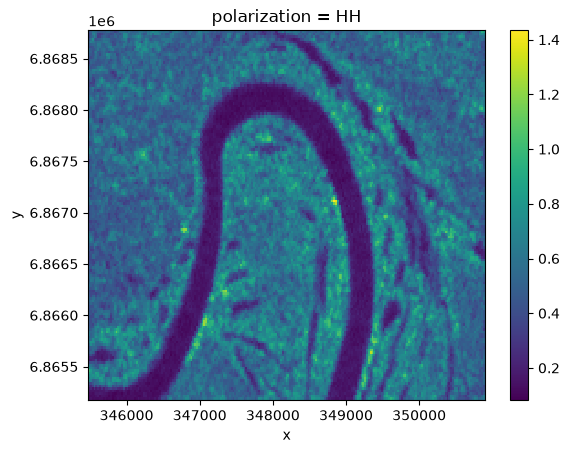

In [39]:
lut_da.isel(polarization=0).mean(dim="id").plot.imshow()

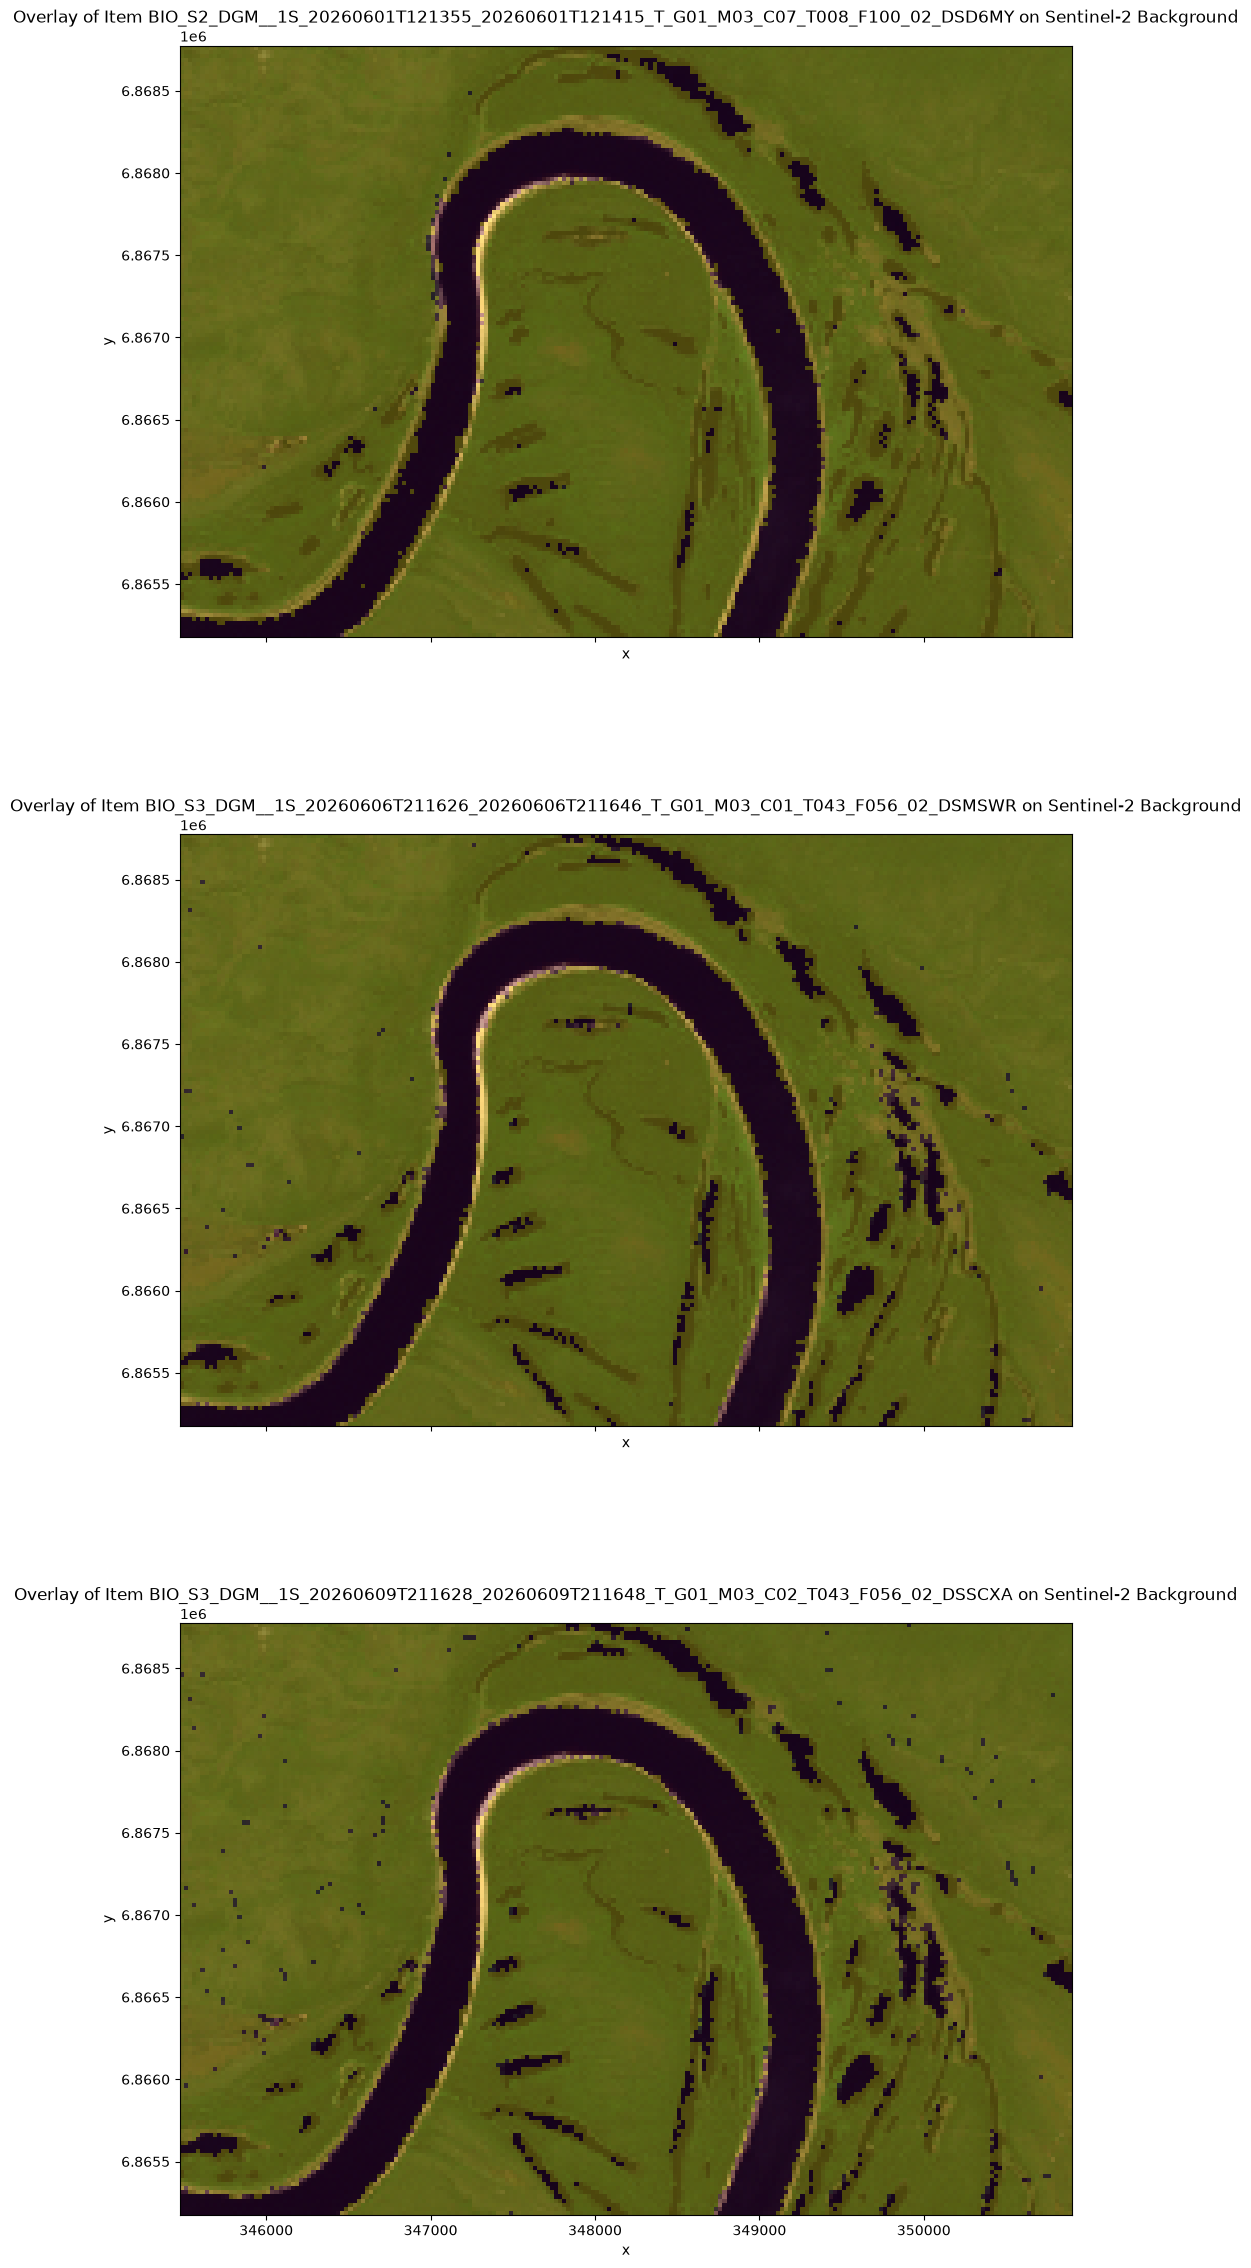

In [40]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 24), sharex=True, sharey=True)

for i, (item_id, ax) in enumerate(zip(gcp_da.id.values, axes)):
    
    s2_da.plot.imshow(rgb="band", ax=ax)

    lut_water_mask.sel(id=item_id).plot.imshow(
        ax=ax, 
        alpha=0.3, 
        cmap="viridis",
        vmin=0,
        vmax=1,
        add_colorbar=False,
    )
    
    ax.set_title(f"Overlay of Item {item_id} on Sentinel-2 Background")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

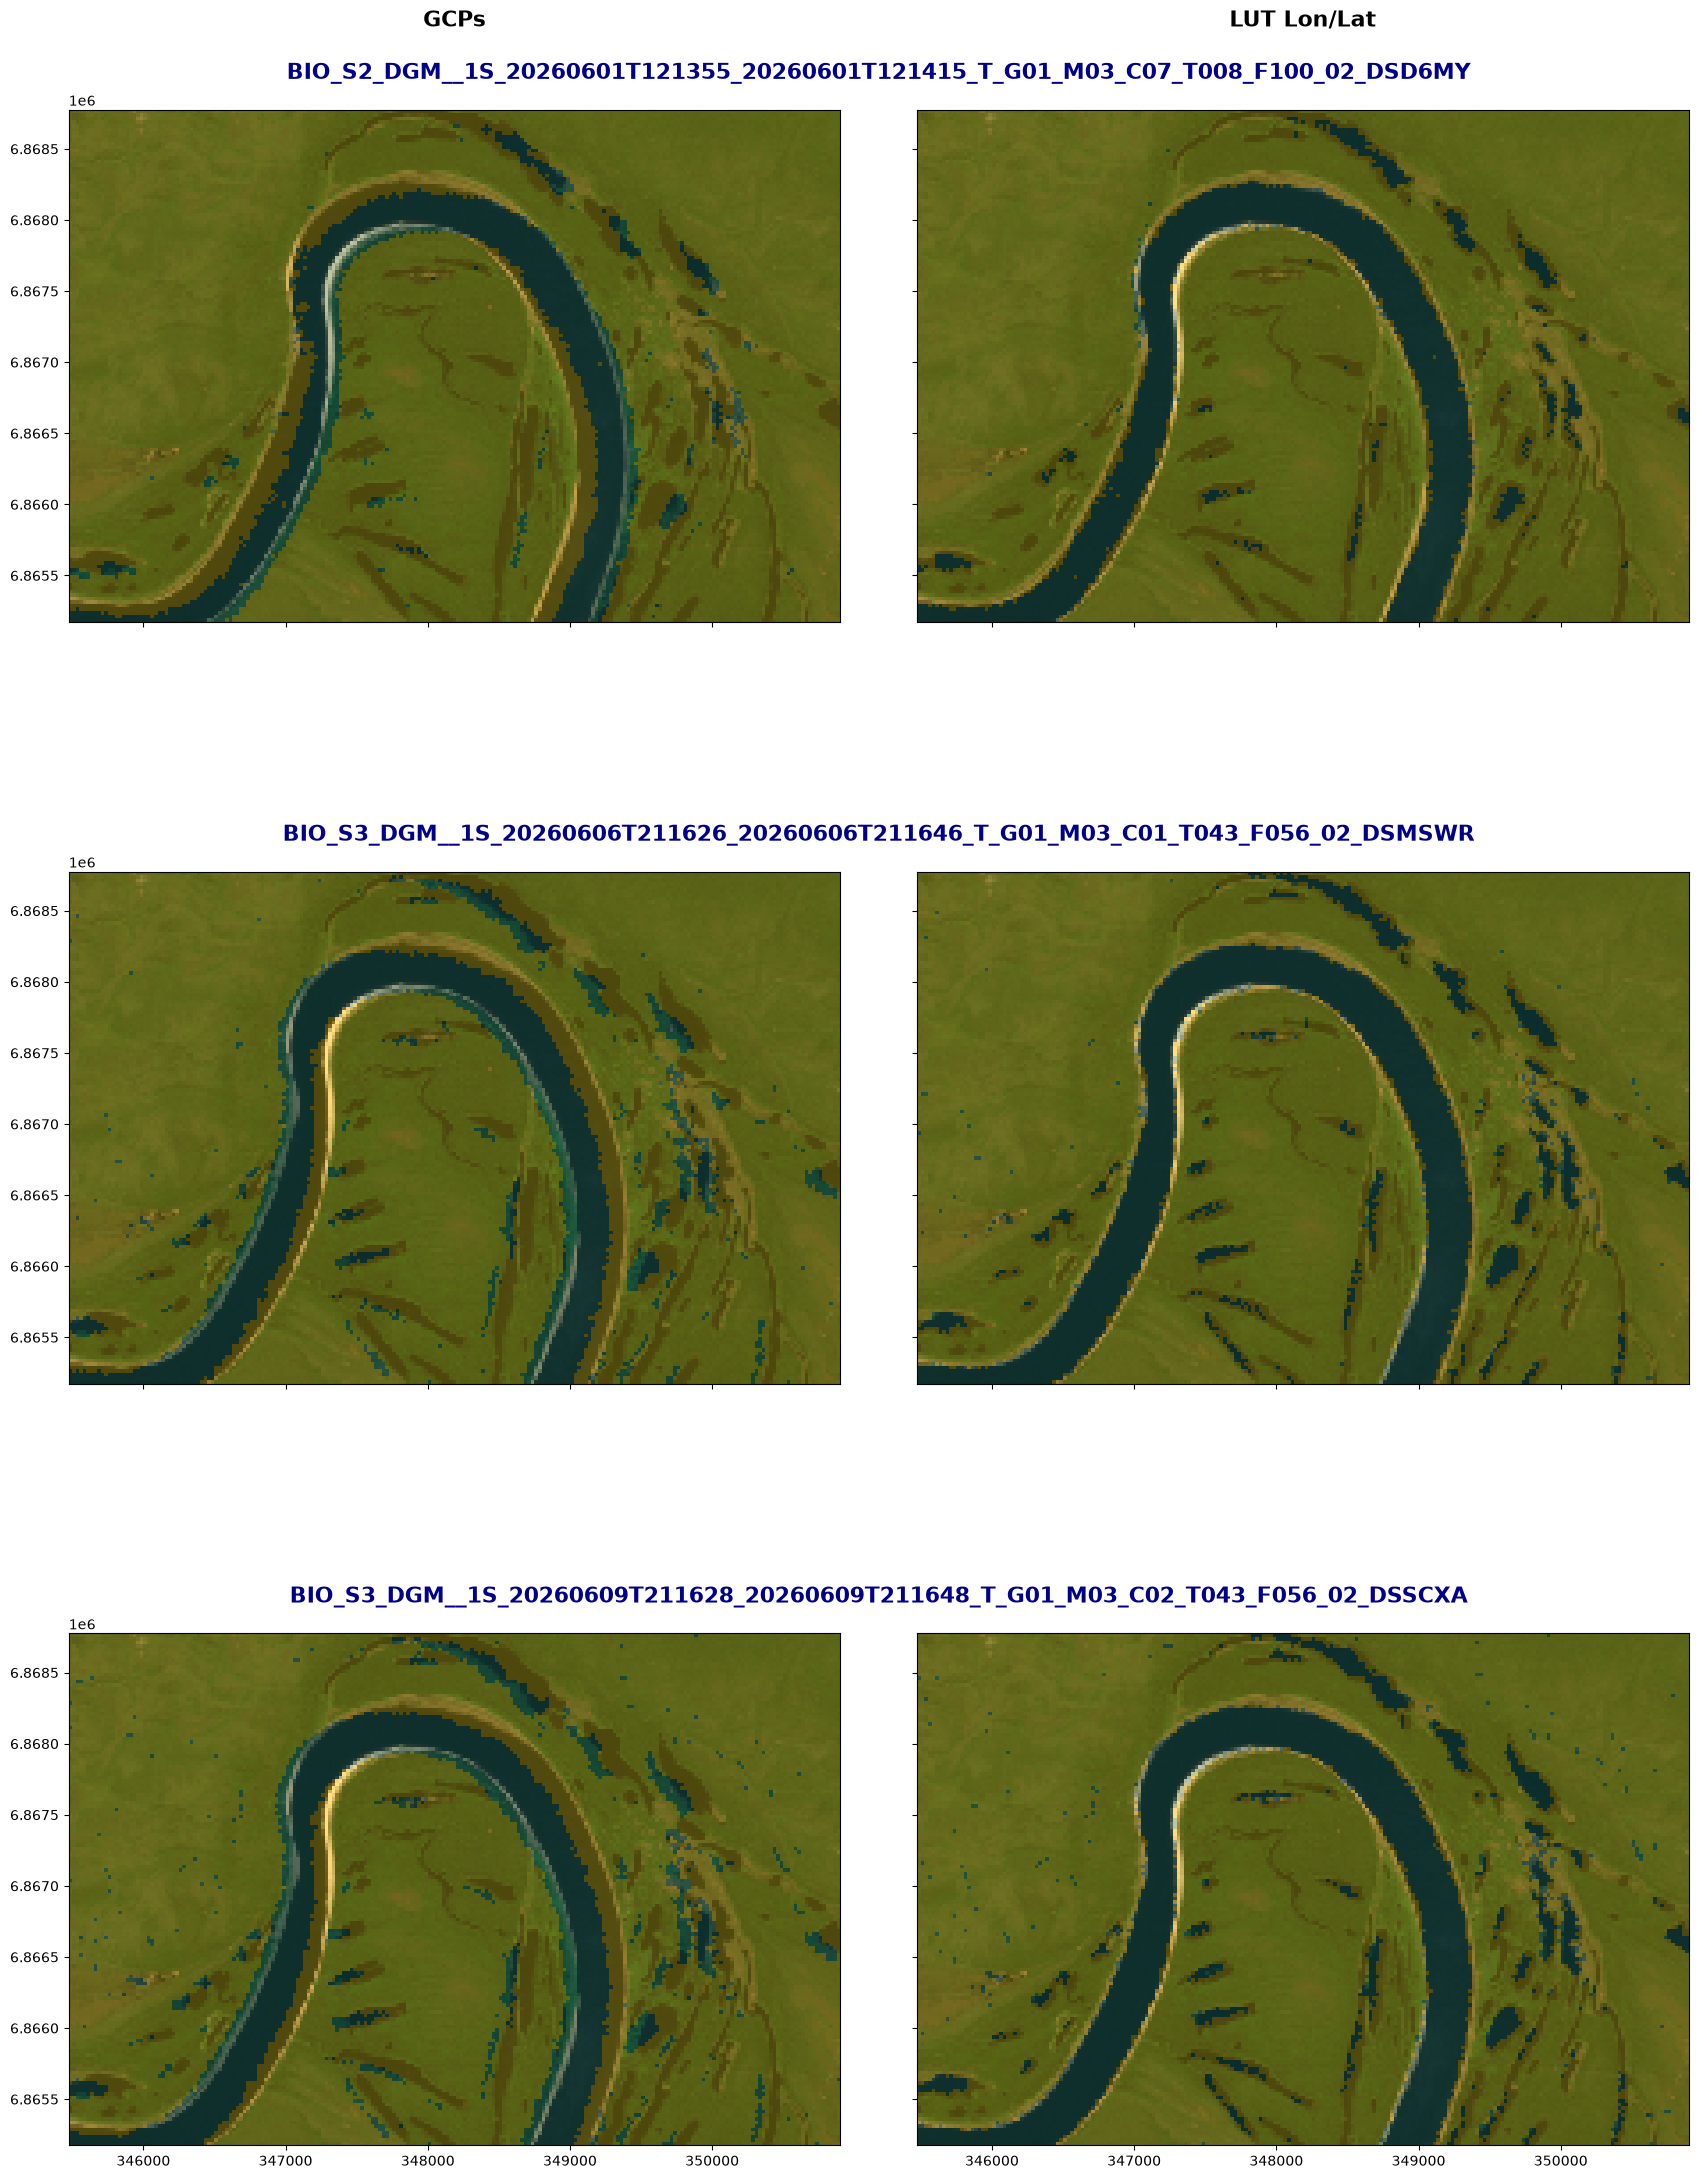

In [41]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 24), sharex=True, sharey=True)
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.92, hspace=0.35, wspace=0.1)
column_labels = ["GCPs", "LUT Lon/Lat"]
for i, item_id in enumerate(gcp_da.id.values):
    ax_col1 = axes[i, 0]

    s2_da.plot.imshow(rgb="band", ax=ax_col1)
    
    gcp_water_mask.sel(
        id=item_id
    ).plot.imshow(ax=ax_col1, alpha=0.3, cmap="viridis", vmin=0, vmax=0, add_colorbar=False)
    
    ax_col1.set_ylabel(f"Item: {item_id}", fontsize=14, fontweight="bold", rotation=90, labelpad=20)
    ax_col1.set_aspect("equal")
    
    ax_col2 = axes[i, 1]
        
    s2_da.plot.imshow(rgb="band", ax=ax_col2)
    
    lut_water_mask.sel(
        id=item_id
    ).plot.imshow(ax=ax_col2, alpha=0.3, cmap="viridis", vmin=0, vmax=0, add_colorbar=False)
    
    ax_col2.set_aspect("equal")

    for ax in [ax_col1, ax_col2]:
        ax.set_ylabel("")
        ax.set_xlabel("")

    pos1 = ax_col1.get_position()
    pos2 = ax_col2.get_position()
    
    # ------------------ PERFECTLY CENTERED ROW LABELS ------------------
    # 'transform=ax_col1.transAxes' anchors our math strictly to the first image box.
    # x=1.05 aligns it right in the middle gutter between the left and right images.
    # y=1.05 hovers it uniformly above the top edge of BOTH images on this row.
    ax_col1.text(
        x=1.05, 
        y=1.05, 
        s=item_id, 
        transform=ax_col1.transAxes, 
        fontsize=16, 
        fontweight="bold", 
        color="darkblue",
        ha="center", 
        va="bottom"
    )
    
    # ------------------ COLUMN LABELS (Top Row Only) ------------------
    if i == 0:
        ax_col1.set_title(column_labels[0], fontsize=16, fontweight="bold", pad=60)
        ax_col2.set_title(column_labels[1], fontsize=16, fontweight="bold", pad=60)
    else:
        # Prevent lower rows from drawing automatic titles
        ax_col1.set_title("")
        ax_col2.set_title("")

plt.savefig("biomass-georeferencing-comparison.png")
plt.show()

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharex=True, sharey=True)
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.92, hspace=0.35, wspace=0.1)
column_labels = ["GCPs", "LUT Lon/Lat"]


ax_col1 = axes[i, 0]

s2da.plot.imshow(rgb="band", ax=ax_col1)

overlay_1 = gcp_da.sel(id=item_id, polarization=["HH", "HV", "VV"])
overlay_1.plot.imshow(ax=ax_col1, alpha=0.5, rgb="polarization")

ax_col1.set_ylabel(f"Item: {item_id}", fontsize=14, fontweight="bold", rotation=90, labelpad=20)
ax_col1.set_aspect("equal")

ax_col2 = axes[i, 1]
    
s2da.plot.imshow(rgb="band", ax=ax_col2)

overlay_2 = lut_da.sel(id=item_id, polarization=["HH", "HV", "VV"])
overlay_2.plot.imshow(ax=ax_col2, alpha=0.5, rgb="polarization")

ax_col2.set_aspect("equal")

for ax in [ax_col1, ax_col2]:
    ax.set_ylabel("")
    ax.set_xlabel("")

pos1 = ax_col1.get_position()
pos2 = ax_col2.get_position()

# ------------------ PERFECTLY CENTERED ROW LABELS ------------------
# 'transform=ax_col1.transAxes' anchors our math strictly to the first image box.
# x=1.05 aligns it right in the middle gutter between the left and right images.
# y=1.05 hovers it uniformly above the top edge of BOTH images on this row.
ax_col1.text(
    x=1.05, 
    y=1.05, 
    s=item_id, 
    transform=ax_col1.transAxes, 
    fontsize=16, 
    fontweight="bold", 
    color="darkblue",
    ha="center", 
    va="bottom"
)

ax_col1.set_title(column_labels[0], fontsize=16, fontweight="bold", pad=60)
ax_col2.set_title(column_labels[1], fontsize=16, fontweight="bold", pad=60)

plt.savefig("biomass-georeferencing-comparison.png")
plt.show()